# Proyecto - Parte 1: Machine Learning clásico

**Competencia:** clasificación de reseñas de productos en español

**Estudiantes:**

[Nombre integrante 1] – [código]

[Nombre integrante 2] – [código]

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto

En esta primera parte del proyecto se deben clasificar reseñas de productos escritas en español en tres categorías: `positivo`, `negativo` y `neutral`. Se cuenta con 12.000 reseñas etiquetadas (`train.csv`) y 3.000 reseñas sin etiqueta (`eval.csv`), sobre las cuales se deben enviar predicciones a la competencia de Kaggle.

## Requisitos de la guía y cómo se cumplen

| Requisito | Cómo se cumple en este notebook |
|:---|:---|
| No usar aprendizaje profundo, transformers ni embeddings preentrenados. | No se usa ninguno. El texto se representa con TF-IDF y n-gramas. |
| Usar únicamente modelos de clasificación de scikit-learn. | `LogisticRegression`, `MultinomialNB`, `KNeighborsClassifier`, `DecisionTreeClassifier` y `RandomForestClassifier`. |
| Usar solo técnicas de representación de texto de la primera parte del curso. | Normalización, tokenización, stop words, stemming, TF-IDF y n-gramas, combinados con `Pipeline`, `ColumnTransformer`, `FunctionTransformer` y `GridSearchCV`. |
| Subir un único modelo, el del mejor resultado. | Se entrega `models/regresion_logistica_bloques.joblib`, que es el mejor modelo según la sección 10 y el que produce `submissions/submission_regresion_logistica_bloques.csv`. |
| Resultados replicables. | Semilla fija (`RANDOM_STATE = 42`), versiones de las librerías en `requirements.txt` y todo el flujo en este notebook (ver sección 16). |

## Contenido

1. Importación de librerías
2. Carga de los datos
3. Exploración de los datos
4. Partición de los datos
5. Preprocesamiento del texto
6. Línea base: TF-IDF del texto completo
7. ¿Dónde se equivoca la línea base?
8. Representación por bloques
9. Modelos y búsqueda de hiperparámetros
10. Comparación de modelos y selección del mejor
11. Evaluación del mejor modelo
12. Interpretación del modelo
13. Modelo final y predicciones para la competencia
14. Conclusiones
15. Uso de herramientas de IA generativa
16. Cómo replicar los resultados

## 1. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     cross_validate, train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

try:
    stopwords.words('spanish')
except LookupError:
    nltk.download('stopwords')

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
NOMBRE_MODELO = 'regresion_logistica_bloques'

os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 2. Carga de los datos

Se cargan los tres archivos de la competencia: `train.csv` (id, texto y etiqueta), `eval.csv` (id y texto, sin etiqueta) y `sample_submission.csv` (formato de envío con las columnas `id` y `answer`). Como la etiqueta de `eval.csv` no se conoce, todas las decisiones de modelado se toman únicamente con `train.csv`.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
train.head()

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)


,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo p...",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea di...",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficin...",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por...",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. ...",positivo


## 3. Exploración de los datos

### 3.1 Distribución de la variable objetivo

,conteo,proporcion (%)
label,,
negativo,4212,35.1
neutral,3576,29.8
positivo,4212,35.1


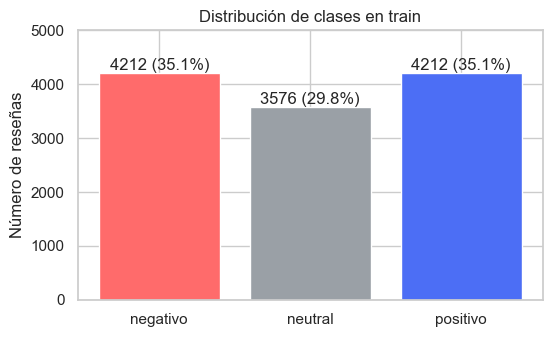

In [3]:
conteo = train['label'].value_counts().reindex(ORDEN_CLASES)
tabla_clases = pd.DataFrame({'conteo': conteo, 'proporcion (%)': (conteo / len(train) * 100).round(1)})
display(tabla_clases)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(conteo.index, conteo.values, color=['#FF6B6B', '#9AA0A6', '#4C6EF5'])
for i, v in enumerate(conteo.values):
    ax.text(i, v + 60, f'{v} ({v / len(train) * 100:.1f}%)', ha='center')
ax.set(title='Distribución de clases en train', ylabel='Número de reseñas', ylim=(0, 5000))
plt.show()

Las clases `positivo` y `negativo` tienen el mismo número de reseñas (4.212 cada una, 35,1%) y `neutral` tiene 3.576 (29,8%). El desbalance es leve, por lo que no se aplica ninguna técnica de balanceo; de todas formas, `class_weight` se incluye como hiperparámetro de la regresión logística (sección 9.1).

Como las clases no tienen exactamente el mismo tamaño, la métrica principal para comparar modelos es el F1-macro, que promedia el F1 de las tres clases dándoles el mismo peso. La exactitud también se reporta.

### 3.2 Calidad de los datos

In [4]:
print('Valores nulos en train:', train.isna().sum().sum())
print('Valores nulos en eval:', evaluacion.isna().sum().sum())
print('Textos duplicados en train:', train['text'].duplicated().sum())
print('Textos de eval que también aparecen en train:', len(set(evaluacion['text']) & set(train['text'])))
print('ids únicos en train:', train['id'].is_unique, '| ids únicos en eval:', evaluacion['id'].is_unique)
print('Mismos ids y mismo orden en eval y sample_submission:', (evaluacion['id'] == muestra_envio['id']).all())

Valores nulos en train: 0
Valores nulos en eval: 0
Textos duplicados en train: 0
Textos de eval que también aparecen en train: 0
ids únicos en train: True | ids únicos en eval: True
Mismos ids y mismo orden en eval y sample_submission: True


### 3.3 Longitud de los textos

,train,eval
count,12000.0,3000.0
mean,53.9,54.2
std,13.2,13.1
min,3.0,4.0
25%,47.0,48.0
50%,54.0,54.0
75%,61.0,61.0
max,110.0,104.0


Palabras por reseña según la clase (train):


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


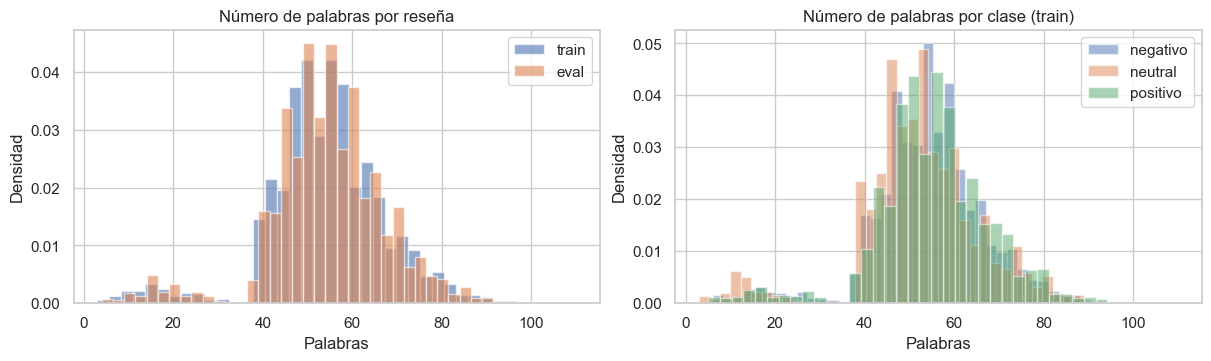

In [5]:
palabras_train = train['text'].str.split().str.len()
palabras_eval = evaluacion['text'].str.split().str.len()

display(pd.DataFrame({'train': palabras_train.describe(), 'eval': palabras_eval.describe()}).round(1))

print('Palabras por reseña según la clase (train):')
display(palabras_train.groupby(train['label']).describe().round(1).reindex(ORDEN_CLASES))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)
ax[0].hist(palabras_train, bins=40, alpha=0.6, density=True, label='train')
ax[0].hist(palabras_eval, bins=40, alpha=0.6, density=True, label='eval')
ax[0].set(title='Número de palabras por reseña', xlabel='Palabras', ylabel='Densidad')
ax[0].legend()

for clase in ORDEN_CLASES:
    ax[1].hist(palabras_train[train['label'] == clase], bins=40, alpha=0.5, density=True, label=clase)
ax[1].set(title='Número de palabras por clase (train)', xlabel='Palabras', ylabel='Densidad')
ax[1].legend()
plt.show()

Las reseñas de train y eval tienen una distribución de longitud casi idéntica (media cercana a 54 palabras), por lo que no hay señales de que los datos de la competencia sean distintos a los de entrenamiento. Entre clases las diferencias son pequeñas, así que la longitud por sí sola no es un buen predictor. En los histogramas se observa un grupo pequeño de reseñas cortas (menos de unas 35 palabras), algo más frecuente en `neutral`.

### 3.4 Tildes y errores de escritura

In [6]:
patron_marcas = '[áéíóúüñ¿¡]'
sin_marcas_train = (~train['text'].str.contains(patron_marcas)).mean()
sin_marcas_eval = (~evaluacion['text'].str.contains(patron_marcas)).mean()
print(f'Textos sin ninguna tilde, ñ ni signo de apertura -> train: {sin_marcas_train:.1%} | eval: {sin_marcas_eval:.1%}')

print('\nEjemplos de errores de escritura:')
for palabra in ['epsectacular', 'lleego', 'tamaano', 'familir']:
    print(f'  "{palabra}" aparece en {train["text"].str.contains(palabra).sum()} reseña(s) de train')

Textos sin ninguna tilde, ñ ni signo de apertura -> train: 31.3% | eval: 31.4%

Ejemplos de errores de escritura:
  "epsectacular" aparece en 1 reseña(s) de train
  "lleego" aparece en 2 reseña(s) de train
  "tamaano" aparece en 1 reseña(s) de train
  "familir" aparece en 1 reseña(s) de train


Cerca del 31% de las reseñas, tanto en train como en eval, no tiene ninguna tilde, ñ ni signo de apertura, lo que indica que una parte de los textos viene escrita sin tildes (por ejemplo, "dias" o "ano"). También aparecen algunas palabras con errores de digitación, aunque son poco frecuentes (cada ejemplo mostrado aparece en una o dos reseñas).

Si no se normaliza el texto, una misma palabra ("más" y "mas", "día" y "dia") queda como dos términos distintos en el vocabulario y el modelo tiene que aprender cada variante por separado. Por eso en el preprocesamiento se eliminan las tildes.

### 3.5 Ejemplos por clase

In [7]:
for clase in ORDEN_CLASES:
    print(f'===== {clase} =====')
    for texto in train.loc[train['label'] == clase, 'text'].sample(3, random_state=7):
        print('-', texto, '\n')

===== negativo =====
- Lo compré hace un par de meses para usar en casa, nada del otro mundo en cuanto a envío, llegó en unos cuatro días. El soporte técnico vale totalmente la pena, la verdad me atendieron cuando llamé por una duda de instalación. Por otro lado, le pondría una estrella al menú de ajustes. Total, que tengo sentimientos encontrados con esto. 

- Desde hace varios meses se lo compré a un familiar, lo pedí un jueves y me llegó al día siguiente. El cable es sobresaliente comparado con otros que he tenido, la verdad. Ya lo uso a diario en el escritorio de la casa. Eso sí, al final la atención al cliente me resultó ser débil hasta ahora, y eso que les escribí un par de veces por el tema de la garantía. 

- Me decidí por la versión con ensamblaje cuando lo pedí, y me alegra haber elegido el ensamblaje, llegó armado y listo para usar en mi oficina. Eso sí, la duración de la carga fue un error de compra, no me la esperaba así después de leer las especificaciones. La uso a diari

Hay una diferencia clara entre las clases. Las reseñas `neutral` describen características objetivas del producto (voltaje, garantía, tamaño, tipo de pilas, tiempo de envío) sin emitir ningún juicio. Las reseñas `positivo` y `negativo`, en cambio, contienen juicios sobre aspectos del producto, y con frecuencia mezclan una opinión positiva y una negativa en la misma reseña (por ejemplo, un texto que elogia el cable y luego dice que la atención al cliente fue débil).

Esto anticipa que separar `neutral` será fácil y que la dificultad estará en distinguir `positivo` de `negativo`. Además, varias reseñas terminan con frases ambiguas como "cada quien que juzgue" o "tengo sentimientos encontrados", que no indican cuál es la etiqueta.

## 4. Partición de los datos

Se separa el 20% de las reseñas etiquetadas como conjunto de prueba, de forma estratificada para conservar la proporción de clases. Este conjunto no se usa para elegir hiperparámetros ni representaciones. La selección se hace con validación cruzada estratificada de 5 particiones sobre el 80% restante, y el conjunto de prueba solo sirve para estimar el desempeño de los modelos ya elegidos.

Al final, la configuración seleccionada se vuelve a entrenar con las 12.000 reseñas para generar las predicciones de la competencia (sección 13).

In [8]:
X = train[['text']]
y = train['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)
display(pd.DataFrame({'train': y_train.value_counts(normalize=True),
                      'test': y_test.value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Entrenamiento: (9600, 1) | Prueba: (2400, 1)


,train,test
label,,
negativo,0.351,0.351
neutral,0.298,0.298
positivo,0.351,0.351


## 5. Preprocesamiento del texto

El preprocesamiento sigue el pipeline visto en la práctica de preparación de textos (normalización, tokenización, stop words y stemming). La función `limpiar_texto` hace lo siguiente:

1. Convierte el texto a minúsculas y elimina las tildes (y la tilde de la ñ), para que 'más' y 'mas' sean el mismo término.
2. Reemplaza los signos de puntuación y los números por espacios.
3. Separa el texto en palabras.
4. Opcionalmente elimina stop words.
5. Opcionalmente reduce cada palabra a su raíz con `SnowballStemmer('spanish')` de NLTK.

Como el stemming se aplica una y otra vez a las mismas palabras durante la validación cruzada, se guarda la raíz de cada palabra en un diccionario para que no se recalcule.

In [9]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


# Stop words de NLTK sin tildes, para que coincidan con el texto ya normalizado
stop_nltk = {quitar_tildes(p) for p in stopwords.words('spanish')}

# Palabras de la lista de NLTK que expresan negación, contraste o intensidad
negaciones = {'no', 'ni', 'nada', 'nunca', 'ningun', 'sin', 'pero', 'muy', 'mas', 'poco',
              'mucho', 'tanto', 'si', 'aunque'}
stop_sin_negaciones = stop_nltk - negaciones


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


ejemplo = X_train['text'].iloc[1]
print('ORIGINAL:\n', ejemplo)
print('\nLIMPIO (sin tildes, sin signos, con stemming):\n', limpiar_texto(ejemplo))

ORIGINAL:
 Hace unos dias, lo uso a diario. La verdad, el material me reslto optimo la verdad. Con todo, el material se ve defectuoso la verdad.

LIMPIO (sin tildes, sin signos, con stemming):
 hac unos dias lo uso a diari la verd el material me reslt optim la verd con tod el material se ve defectu la verd


### 5.1 Efecto de cada decisión de preprocesamiento

Para decidir qué pasos incluir, se mide el efecto de cada uno con una línea de referencia simple: TF-IDF con unigramas y bigramas sobre el texto completo y regresión logística, evaluada con validación cruzada sobre el conjunto de entrenamiento.

In [10]:
def preparar(textos, stop=None, stemming=True):
    return [limpiar_texto(t, stop, stemming) for t in textos]


def evaluar_cv(nombre, pipeline, X_ent, y_ent):
    puntajes = cross_validate(pipeline, X_ent, y_ent, cv=kfold, scoring=['accuracy', 'f1_macro'], n_jobs=-1)
    return {'Variante': nombre,
            'Exactitud (CV)': puntajes['test_accuracy'].mean(),
            'F1-macro (CV)': puntajes['test_f1_macro'].mean(),
            'Desv. F1-macro': puntajes['test_f1_macro'].std()}


def pipeline_texto_completo(**kw_prep):
    return Pipeline([
        ('prep', FunctionTransformer(preparar, kw_args=kw_prep)),
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
        ('modelo', LogisticRegression(C=3, max_iter=3000, random_state=RANDOM_STATE)),
    ])


filas = []

# Sin ningún preprocesamiento propio: solo lo que hace TfidfVectorizer por defecto
crudo = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
                  ('modelo', LogisticRegression(C=3, max_iter=3000, random_state=RANDOM_STATE))])
filas.append(evaluar_cv('Texto crudo (TfidfVectorizer por defecto)', crudo, X_train['text'], y_train))

variantes = {
    'Minúsculas, sin tildes ni signos': dict(stop=None, stemming=False),
    'Anterior + stemming': dict(stop=None, stemming=True),
    'Stop words NLTK': dict(stop=stop_nltk, stemming=False),
    'Stop words NLTK + stemming': dict(stop=stop_nltk, stemming=True),
    'Stop words NLTK sin negaciones + stemming': dict(stop=stop_sin_negaciones, stemming=True),
}
for nombre, kw in variantes.items():
    filas.append(evaluar_cv(nombre, pipeline_texto_completo(**kw), X_train['text'], y_train))

tabla_prep = pd.DataFrame(filas).set_index('Variante')
tabla_prep.round(4)

,Exactitud (CV),F1-macro (CV),Desv. F1-macro
Variante,,,
Texto crudo (TfidfVectorizer por defecto),0.7282,0.7396,0.0155
"Minúsculas, sin tildes ni signos",0.7329,0.7440,0.0158
Anterior + stemming,0.7327,0.7437,0.0143
Stop words NLTK,0.7203,0.7315,0.0133
Stop words NLTK + stemming,0.7167,0.7277,0.0103
Stop words NLTK sin negaciones + stemming,0.7279,0.7391,0.0113


Las diferencias entre variantes son pequeñas frente a la desviación entre particiones (cerca de 0,014 de F1-macro), así que hay que leerlas con cuidado. Lo que se observa es lo siguiente:

- Normalizar (minúsculas, sin tildes ni signos) mejora levemente frente al texto crudo (0,7440 frente a 0,7396 de F1-macro), de acuerdo con lo visto en la exploración.
- El stemming prácticamente no cambia el resultado en esta línea de referencia (0,7437), pero reduce el vocabulario y hace parte del pipeline visto en clase, por lo que se mantiene.
- Las stop words **empeoran** el resultado (0,7315 con la lista de NLTK y 0,7277 si además se aplica stemming). La lista de NLTK elimina palabras como "no", "pero", "muy", "sin" o "ni", que en un texto de opiniones son las que cambian o matizan el sentimiento (el mismo caso del ejercicio 1 de la práctica de preparación de textos, donde quitar "no" invierte el significado). Incluso conservando esas palabras (0,7391) no se supera el resultado de no eliminar stop words.

Se decide entonces usar minúsculas, sin tildes ni signos, con stemming y **sin eliminar stop words**.

## 6. Línea base: TF-IDF del texto completo

Como punto de partida se hace lo que se haría siguiendo literalmente lo visto en clase: TF-IDF con unigramas y bigramas sobre el texto completo ya preprocesado, y un clasificador. Se prueban dos modelos: regresión logística y Naive Bayes multinomial.

In [11]:
def metricas(y_real, y_pred):
    return {'Exactitud': accuracy_score(y_real, y_pred),
            'Precisión (macro)': precision_score(y_real, y_pred, average='macro'),
            'Recall (macro)': recall_score(y_real, y_pred, average='macro'),
            'F1 (macro)': f1_score(y_real, y_pred, average='macro')}


base_lr = pipeline_texto_completo(stemming=True)
base_nb = Pipeline([
    ('prep', FunctionTransformer(preparar)),
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('modelo', MultinomialNB(alpha=0.3)),
])

pred_base = {}
for nombre, pipe in [('Regresión logística', base_lr), ('Naive Bayes', base_nb)]:
    pipe.fit(X_train['text'], y_train)
    pred_base[nombre] = pipe.predict(X_test['text'])

pd.DataFrame({n: metricas(y_test, p) for n, p in pred_base.items()}).T.round(4)

,Exactitud,Precisión (macro),Recall (macro),F1 (macro)
Regresión logística,0.7283,0.7395,0.7420,0.7407
Naive Bayes,0.7171,0.7295,0.7309,0.7302


              precision    recall  f1-score   support

    negativo      0.615     0.626     0.620       843
     neutral      0.983     1.000     0.992       715
    positivo      0.620     0.600     0.610       842

    accuracy                          0.728      2400
   macro avg      0.740     0.742     0.741      2400
weighted avg      0.727     0.728     0.727      2400



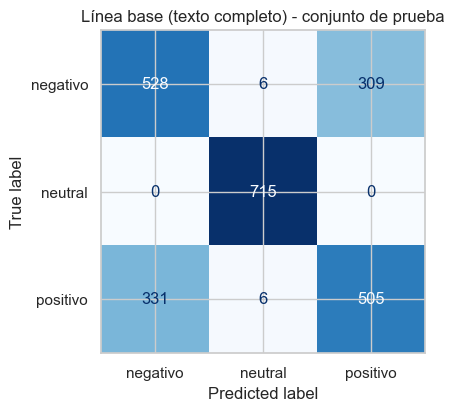

In [12]:
y_pred_base = pd.Series(pred_base['Regresión logística'], index=y_test.index)
print(classification_report(y_test, y_pred_base, digits=3))

fig, ax = plt.subplots(figsize=(5, 4.2))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, labels=ORDEN_CLASES, cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Línea base (texto completo) - conjunto de prueba')
plt.show()

La línea base alcanza una exactitud de 0,728 y un F1-macro de 0,741 en el conjunto de prueba. La clase `neutral` se clasifica casi perfectamente (recall de 1,000 y F1 de 0,992), pero `positivo` y `negativo` apenas llegan a un F1 de 0,61 y 0,62 y se confunden entre sí. Naive Bayes da un resultado parecido (F1-macro de 0,730), por lo que el problema parece estar en la representación y no en el algoritmo.

## 7. ¿Dónde se equivoca la línea base?

En la matriz de confusión anterior casi todos los errores son reseñas positivas clasificadas como negativas y viceversa. Para entender por qué, se revisan algunos de esos errores en el conjunto de prueba, mostrando la reseña oración por oración.

In [13]:
def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


errores = y_test[(y_test != y_pred_base) & (y_test != 'neutral')].index
for i in errores[:5]:
    print(f'[real: {y_test[i]} | predicho: {y_pred_base[i]}]')
    for oracion in separar_oraciones(X_test.loc[i, 'text']):
        print('   -', oracion)
    print()

[real: negativo | predicho: positivo]
   - Compré este equipo a mediados de mayo y llegó en unos cuatro días a mi casa aquí en Guadalajara.
   - Lo conecté el mismo día que llegó y lo uso principalmente para ver películas en la sala.
   - La verdad, el sistema de sonido quedó sobresaliente comparado con otros, pero la conexión terminó siendo lentísima a decir verdad.

[real: positivo | predicho: negativo]
   - Lo compré hace unos días por internet y llegó en tres días.
   - Lo estoy probando a fondo, sobre todo los fines de semana en casa.
   - Usa una batería de litio, eso sí está en las especificaciones.
   - La verdad, el diseño quedó poco fiable desde que lo estrené.
   - Eso sí, la interfaz me resultó ser muy completa desde el primer día.

[real: positivo | predicho: negativo]
   - Comento con calma: la pantalla táctil se merece cinco estrellas.
   - Lo compré a mediados de mes y llegó en tres días a mi casa, con la caja sellada y todo bien.
   - Lo tengo en la sala para el día a 

En cuatro de estos cinco ejemplos la reseña contiene una opinión positiva y otra negativa, y la etiqueta coincide con la opinión que aparece al final. Por ejemplo, "sobresaliente [...] pero la conexión terminó siendo lentísima" es `negativo`, y "ordinario [...] Con todo, el motor me salió resistente" es `positivo`. Una bolsa de palabras sobre el texto completo no distingue "bueno... pero malo" de "malo... pero bueno": ambas contienen las mismas palabras, el orden se pierde y los bigramas solo capturan el contexto inmediato.

Para comprobar si la posición de la opinión importa, se entrena el mismo modelo viendo solo la primera oración, solo la última o el texto completo. Las reseñas tienen entre 1 y 7 oraciones y la mayoría tiene 4.

In [14]:
def extraer_primera(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[0], stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


print('Oraciones por reseña:')
print(pd.Series([len(separar_oraciones(t)) for t in X_train['text']]).value_counts().sort_index().to_string())

filas = []
for nombre, extractor in [('Solo la primera oración', extraer_primera),
                          ('Solo la última oración', extraer_ultima),
                          ('Texto completo', extraer_completo)]:
    pipe = Pipeline([
        ('extraer', FunctionTransformer(extractor)),
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
        ('modelo', LogisticRegression(C=3, max_iter=3000, random_state=RANDOM_STATE)),
    ])
    filas.append(evaluar_cv(nombre, pipe, X_train['text'], y_train))

pd.DataFrame(filas).set_index('Variante').round(4)

Oraciones por reseña:
1     114
2     249
3    1937
4    5692
5    1524
6      83
7       1


,Exactitud (CV),F1-macro (CV),Desv. F1-macro
Variante,,,
Solo la primera oración,0.5113,0.5172,0.0128
Solo la última oración,0.8571,0.8596,0.0121
Texto completo,0.7327,0.7437,0.0143


Con solo la última oración el modelo obtiene un F1-macro de 0,860, mucho más que con el texto completo (0,744), mientras que con solo la primera oración queda en 0,517, es decir, la primera oración casi no aporta. La información que define la etiqueta está concentrada al final de la reseña, y la primera oración suele ser contexto de la compra (envío, uso). Al usar el texto completo, ese contexto diluye la señal.

## 8. Representación por bloques

Con base en el hallazgo anterior se construye una representación con tres bloques de TF-IDF que se concatenan con un `ColumnTransformer`, de la misma manera que en las prácticas anteriores se combinaban columnas con transformaciones distintas:

1. **Texto completo:** todo el texto preprocesado. Sirve para separar `neutral` de las otras dos clases y aporta contexto general.
2. **Última oración:** solo la última oración de la reseña, donde suele estar la opinión que define la etiqueta.
3. **Cláusula final:** dentro de la última oración, el fragmento que sigue al último conector de contraste (`pero`, `aunque`, `sin embargo`, `aun así`, `con todo`, `a fin de cuentas`, `al final`). Cuando hay un conector así, la opinión que cuenta es la que viene después. Por ejemplo, en "la instalación me salió impecable, aunque al final el teclado terminó siendo malísimo" el sentimiento relevante es el del teclado. La lista de conectores se definió leyendo ejemplos del conjunto de entrenamiento.

Cada bloque tiene su propio `TfidfVectorizer`. Así, una palabra como 'malísimo' en la última oración y la misma palabra en el texto completo son atributos distintos, y el modelo puede darles pesos diferentes. Los bloques se implementan con `FunctionTransformer` (extrae el fragmento y lo limpia) seguido de `TfidfVectorizer`, de modo que todo el procesamiento queda dentro del `Pipeline`: el modelo recibe la reseña cruda y devuelve la etiqueta.

In [15]:
# Conectores que introducen la opinión que se impone sobre la anterior
CONECTORES = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|a fin de cuentas|al final)\b'


def extraer_clausula_final(textos, stemming=True):
    salida = []
    for t in textos:
        ultima = quitar_tildes(separar_oraciones(t)[-1].lower())
        salida.append(limpiar_texto(re.split(CONECTORES, ultima)[-1], stemming=stemming))
    return salida


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')


def construir_representacion(bloques=('completo', 'ultima', 'clausula'), rango=(1, 2)):
    extractores = {'completo': extraer_completo,
                   'ultima': extraer_ultima,
                   'clausula': extraer_clausula_final}
    return ColumnTransformer([bloque_tfidf(b, extractores[b], rango) for b in bloques])


ejemplo = next(t for t in X_train['text']
               if re.search(CONECTORES, quitar_tildes(separar_oraciones(t)[-1].lower())))
print('TEXTO:\n', ejemplo)
print('\nBLOQUE "última oración":\n', extraer_ultima([ejemplo])[0])
print('\nBLOQUE "cláusula final":\n', extraer_clausula_final([ejemplo])[0])

TEXTO:
 Hace unos dias, lo uso a diario. La verdad, el material me reslto optimo la verdad. Con todo, el material se ve defectuoso la verdad.

BLOQUE "última oración":
 con tod el material se ve defectu la verd

BLOQUE "cláusula final":
 el material se ve defectu la verd


### 8.1 ¿Cuánto aporta cada bloque?

In [16]:
filas = []
for nombre, bloques in [('Texto completo', ('completo',)),
                        ('Texto completo + última oración', ('completo', 'ultima')),
                        ('Texto completo + última oración + cláusula final', ('completo', 'ultima', 'clausula'))]:
    pipe = Pipeline([('rep', construir_representacion(bloques)),
                     ('modelo', LogisticRegression(C=3, max_iter=3000, random_state=RANDOM_STATE))])
    filas.append(evaluar_cv(nombre, pipe, X_train, y_train))

pd.DataFrame(filas).set_index('Variante').round(4)

,Exactitud (CV),F1-macro (CV),Desv. F1-macro
Variante,,,
Texto completo,0.7327,0.7437,0.0143
Texto completo + última oración,0.8811,0.8859,0.0127
Texto completo + última oración + cláusula final,0.8901,0.8942,0.0132


Cada bloque aporta. Pasar del texto completo a texto completo + última oración sube el F1-macro de 0,744 a 0,886, y agregar la cláusula final lo lleva a 0,894 (la exactitud pasa de 0,733 a 0,881 y luego a 0,890). La mejora es mucho mayor que la desviación entre particiones (cerca de 0,013).

### 8.2 Rango de n-gramas en cada bloque

In [17]:
pipe_rep = Pipeline([('rep', construir_representacion()),
                     ('modelo', LogisticRegression(C=3, max_iter=3000, random_state=RANDOM_STATE))])

grilla_rep = {
    'rep__completo__tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'rep__ultima__tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
    'rep__clausula__tfidf__ngram_range': [(1, 1), (1, 2), (1, 3)],
}

busqueda_rep = GridSearchCV(pipe_rep, grilla_rep, cv=kfold, scoring='f1_macro', n_jobs=-1)
busqueda_rep.fit(X_train, y_train)

res_rep = pd.DataFrame(busqueda_rep.cv_results_)
res_rep = res_rep.rename(columns={'param_rep__completo__tfidf__ngram_range': 'ngramas_completo',
                                  'param_rep__ultima__tfidf__ngram_range': 'ngramas_ultima',
                                  'param_rep__clausula__tfidf__ngram_range': 'ngramas_clausula'})
res_rep[['ngramas_completo', 'ngramas_ultima', 'ngramas_clausula', 'mean_test_score',
         'std_test_score', 'rank_test_score']].sort_values('rank_test_score').head(8).round(4)

,ngramas_completo,ngramas_ultima,ngramas_clausula,mean_test_score,std_test_score,rank_test_score
14,"(1, 2)","(1, 3)","(1, 2)",0.8947,0.0129,1
22,"(1, 2)","(1, 2)","(1, 3)",0.8942,0.0136,2
13,"(1, 2)","(1, 2)","(1, 2)",0.8942,0.0132,3
2,"(1, 1)","(1, 3)","(1, 1)",0.8941,0.0099,4
10,"(1, 1)","(1, 2)","(1, 2)",0.8941,0.0111,5
1,"(1, 1)","(1, 2)","(1, 1)",0.8938,0.0112,6
4,"(1, 2)","(1, 2)","(1, 1)",0.8934,0.0130,7
9,"(1, 1)","(1, 1)","(1, 2)",0.8933,0.0115,8


Las mejores combinaciones están prácticamente empatadas: el F1-macro está entre 0,893 y 0,895, con una desviación de 0,013 entre particiones. La primera de la lista usa hasta trigramas en la última oración, pero la diferencia con usar (1, 2) en los tres bloques (0,8942, posición 3) es de 0,0005.

Se escoge (1, 2) en los tres bloques por ser más simple y producir un vocabulario más pequeño. Es la configuración por defecto de `construir_representacion`.

### 8.3 Una prueba adicional: n-gramas de caracteres

In [18]:
def bloque_caracteres(nombre, extractor):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor, kw_args={'stemming': False})),
                      ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), sublinear_tf=True))]),
            'text')


variantes_chars = {
    'Palabras en los tres bloques (representación elegida)': construir_representacion(),
    'Palabras + caracteres en última y cláusula': ColumnTransformer(
        construir_representacion().transformers
        + [bloque_caracteres('ultima_car', extraer_ultima), bloque_caracteres('clausula_car', extraer_clausula_final)]),
    'Solo caracteres en los tres bloques': ColumnTransformer([
        bloque_caracteres('completo_car', extraer_completo),
        bloque_caracteres('ultima_car', extraer_ultima),
        bloque_caracteres('clausula_car', extraer_clausula_final)]),
}

filas = []
for nombre, rep in variantes_chars.items():
    pipe = Pipeline([('rep', rep), ('modelo', LogisticRegression(C=3, max_iter=3000, random_state=RANDOM_STATE))])
    filas.append(evaluar_cv(nombre, pipe, X_train, y_train))

pd.DataFrame(filas).set_index('Variante').round(4)

,Exactitud (CV),F1-macro (CV),Desv. F1-macro
Variante,,,
Palabras en los tres bloques (representación elegida),0.8901,0.8942,0.0132
Palabras + caracteres en última y cláusula,0.8882,0.8919,0.0112
Solo caracteres en los tres bloques,0.8867,0.8912,0.0105


Como en la exploración se vieron errores de digitación, se prueban también n-gramas de caracteres (de 2 a 5 dentro de cada palabra), que son más robustos a ese tipo de errores. No mejoran el resultado (0,8919 y 0,8912 frente a 0,8942), probablemente porque esos errores son poco frecuentes. Se descartan y se mantiene la representación por palabras.

## 9. Modelos y búsqueda de hiperparámetros

Se comparan los cinco algoritmos de clasificación vistos en el curso: regresión logística, Naive Bayes, KNN, árbol de decisión y Random Forest. Todos usan la misma representación por bloques (sección 8) dentro de un `Pipeline`, y cada uno tiene su propia búsqueda de hiperparámetros con `GridSearchCV`, validación cruzada estratificada de 5 particiones y F1-macro como métrica. Todo se hace únicamente sobre el conjunto de entrenamiento; el conjunto de prueba se usa al final para reportar el desempeño.

No se aplica SMOTE: la librería `imbalanced-learn` no hace parte de scikit-learn y el desbalance de clases es leve. Como alternativa de scikit-learn, el parámetro `class_weight` se incluye en la búsqueda de la regresión logística.

In [19]:
resultados = {}


def buscar_hiperparametros(nombre, modelo, grilla):
    pipe = Pipeline([('rep', construir_representacion()), ('modelo', modelo)])
    busqueda = GridSearchCV(pipe, grilla, cv=kfold, scoring='f1_macro', n_jobs=-1)
    busqueda.fit(X_train, y_train)

    y_pred = busqueda.predict(X_test)
    resultados[nombre] = {'busqueda': busqueda, 'y_pred': y_pred,
                          'cv_f1': busqueda.best_score_, **metricas(y_test, y_pred)}

    print('Mejores hiperparámetros:', busqueda.best_params_)
    print(f'F1-macro en validación cruzada: {busqueda.best_score_:.4f}')
    print(f'Prueba -> exactitud: {resultados[nombre]["Exactitud"]:.4f} | F1-macro: {resultados[nombre]["F1 (macro)"]:.4f}')


def resumen_busqueda(nombre, n=5):
    r = pd.DataFrame(resultados[nombre]['busqueda'].cv_results_)
    columnas = [c for c in r.columns if c.startswith('param_')] + ['mean_test_score', 'std_test_score', 'rank_test_score']
    return r[columnas].sort_values('rank_test_score').head(n).round(4)

### 9.1 Regresión logística

La regresión logística se busca sobre el tipo de regularización (`penalty`), el solver, la fuerza de la regularización (`C`, donde un valor mayor significa menos regularización) y `class_weight`. La grilla se divide en dos bloques porque la regularización L1 solo es compatible con algunos solvers, como se hizo en la práctica de regresión logística.

In [20]:
grilla_lr = [
    {   # Regularización L2
        'modelo__penalty': ['l2'],
        'modelo__solver': ['lbfgs', 'liblinear'],
        'modelo__C': [0.5, 1, 3, 10, 30],
        'modelo__class_weight': [None, 'balanced'],
    },
    {   # Regularización L1
        'modelo__penalty': ['l1'],
        'modelo__solver': ['liblinear'],
        'modelo__C': [0.5, 1, 3, 10, 30],
        'modelo__class_weight': [None, 'balanced'],
    },
]

buscar_hiperparametros('Regresión logística', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), grilla_lr)
resumen_busqueda('Regresión logística')

Mejores hiperparámetros: {'modelo__C': 10, 'modelo__class_weight': None, 'modelo__penalty': 'l1', 'modelo__solver': 'liblinear'}
F1-macro en validación cruzada: 0.8992
Prueba -> exactitud: 0.8946 | F1-macro: 0.8993


,param_modelo__C,param_modelo__class_weight,param_modelo__penalty,param_modelo__solver,mean_test_score,std_test_score,rank_test_score
26,10.0,None,l1,liblinear,0.8992,0.0072,1
27,10.0,balanced,l1,liblinear,0.8988,0.0067,2
25,3.0,balanced,l1,liblinear,0.8985,0.0073,3
24,3.0,None,l1,liblinear,0.8984,0.0078,4
28,30.0,None,l1,liblinear,0.8962,0.0076,5


### 9.2 Naive Bayes multinomial

In [21]:
grilla_nb = {
    'modelo__alpha': [0.01, 0.03, 0.1, 0.3, 1.0],
    'modelo__fit_prior': [True, False],
}

buscar_hiperparametros('Naive Bayes', MultinomialNB(), grilla_nb)
resumen_busqueda('Naive Bayes')

Mejores hiperparámetros: {'modelo__alpha': 0.3, 'modelo__fit_prior': True}
F1-macro en validación cruzada: 0.8858
Prueba -> exactitud: 0.8858 | F1-macro: 0.8895


,param_modelo__alpha,param_modelo__fit_prior,mean_test_score,std_test_score,rank_test_score
6,0.30,True,0.8858,0.0093,1
7,0.30,False,0.8857,0.0092,2
4,0.10,True,0.8854,0.0092,3
5,0.10,False,0.8854,0.0093,4
2,0.03,True,0.8851,0.0085,5


### 9.3 K vecinos más cercanos

In [22]:
grilla_knn = {
    'modelo__n_neighbors': [5, 11, 21, 41],
    'modelo__metric': ['cosine', 'euclidean'],
    'modelo__weights': ['uniform', 'distance'],
}

buscar_hiperparametros('KNN', KNeighborsClassifier(), grilla_knn)
resumen_busqueda('KNN')

Mejores hiperparámetros: {'modelo__metric': 'cosine', 'modelo__n_neighbors': 21, 'modelo__weights': 'distance'}
F1-macro en validación cruzada: 0.7932
Prueba -> exactitud: 0.7963 | F1-macro: 0.8004


,param_modelo__metric,param_modelo__n_neighbors,param_modelo__weights,mean_test_score,std_test_score,rank_test_score
5,cosine,21,distance,0.7932,0.0064,1
4,cosine,21,uniform,0.7914,0.0062,2
13,euclidean,21,distance,0.7900,0.0072,3
12,euclidean,21,uniform,0.7891,0.0063,4
7,cosine,41,distance,0.7879,0.0058,5


### 9.4 Árbol de decisión

In [23]:
grilla_dt = {
    'modelo__criterion': ['gini', 'entropy'],
    'modelo__max_depth': [10, 20, 40, None],
    'modelo__min_samples_leaf': [1, 3, 5],
}

buscar_hiperparametros('Árbol de decisión', DecisionTreeClassifier(random_state=RANDOM_STATE), grilla_dt)
resumen_busqueda('Árbol de decisión')

Mejores hiperparámetros: {'modelo__criterion': 'entropy', 'modelo__max_depth': 40, 'modelo__min_samples_leaf': 1}
F1-macro en validación cruzada: 0.6707
Prueba -> exactitud: 0.6737 | F1-macro: 0.6837


,param_modelo__criterion,param_modelo__max_depth,param_modelo__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
18,entropy,40,1,0.6707,0.0074,1
21,entropy,None,1,0.6698,0.0048,2
19,entropy,40,3,0.6669,0.0114,3
22,entropy,None,3,0.6629,0.0094,4
6,gini,40,1,0.6627,0.0294,5


### 9.5 Random Forest

In [24]:
grilla_rf = {
    'modelo__n_estimators': [200, 400],
    'modelo__max_depth': [None],
    'modelo__min_samples_leaf': [1, 2, 4],
    'modelo__max_features': ['sqrt', 'log2'],
}

buscar_hiperparametros('Random Forest', RandomForestClassifier(random_state=RANDOM_STATE), grilla_rf)
resumen_busqueda('Random Forest')

Mejores hiperparámetros: {'modelo__max_depth': None, 'modelo__max_features': 'log2', 'modelo__min_samples_leaf': 2, 'modelo__n_estimators': 400}
F1-macro en validación cruzada: 0.8422
Prueba -> exactitud: 0.8408 | F1-macro: 0.8458


,param_modelo__max_depth,param_modelo__max_features,param_modelo__min_samples_leaf,param_modelo__n_estimators,mean_test_score,std_test_score,rank_test_score
9,None,log2,2,400,0.8422,0.0137,1
8,None,log2,2,200,0.8278,0.0131,2
11,None,log2,4,400,0.8127,0.0110,3
7,None,log2,1,400,0.8106,0.0099,4
6,None,log2,1,200,0.7907,0.0097,5


Resumen de las búsquedas:

- **Regresión logística:** la mejor configuración usa regularización L1, solver `liblinear` y C = 10 (F1-macro en validación cruzada de 0,8992). Las cinco primeras posiciones son todas L1 con C entre 3 y 30. `class_weight='balanced'` no aporta (0,8988 frente a 0,8992), lo cual es coherente con el desbalance leve.
- **Naive Bayes:** `alpha = 0,3` es el mejor (0,8858). Es el único modelo que se acerca a la regresión logística.
- **KNN:** el mejor usa distancia coseno y 21 vecinos (0,7932).
- **Árbol de decisión:** el mejor usa criterio `entropy` y profundidad máxima de 40 (0,6707).
- **Random Forest:** el mejor usa 400 árboles, `max_features='log2'` y `min_samples_leaf=2` (0,8422). Los mejores valores quedaron en el borde de la grilla (más árboles y menos atributos por división mejoraban el resultado), así que ampliar la búsqueda podría mejorarlo un poco, pero la diferencia con la regresión logística (casi 6 puntos) es grande.

## 10. Comparación de modelos y selección del mejor

,F1-macro (CV),Exactitud (test),Precisión macro (test),Recall macro (test),F1-macro (test)
Regresión logística,0.8992,0.8946,0.8987,0.8998,0.8993
Naive Bayes,0.8858,0.8858,0.8883,0.8914,0.8895
Random Forest,0.8422,0.8408,0.8440,0.8486,0.8458
KNN,0.7932,0.7962,0.7971,0.8054,0.8004
Árbol de decisión,0.6707,0.6738,0.6860,0.6818,0.6837


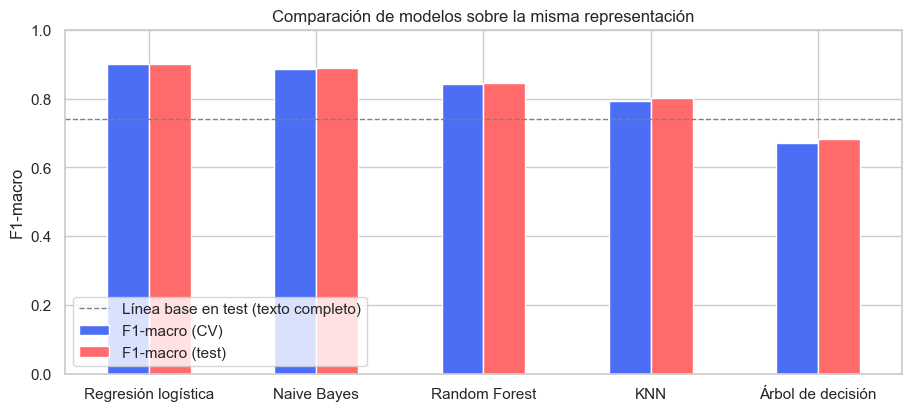

Mejor modelo según F1-macro en validación cruzada: Regresión logística


In [25]:
tabla_modelos = pd.DataFrame(
    {n: {'F1-macro (CV)': r['cv_f1'], 'Exactitud (test)': r['Exactitud'],
         'Precisión macro (test)': r['Precisión (macro)'], 'Recall macro (test)': r['Recall (macro)'],
         'F1-macro (test)': r['F1 (macro)']} for n, r in resultados.items()}
).T.sort_values('F1-macro (CV)', ascending=False)

display(tabla_modelos.round(4))

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
tabla_modelos[['F1-macro (CV)', 'F1-macro (test)']].plot(kind='bar', ax=ax, color=['#4C6EF5', '#FF6B6B'])
ax.set(ylabel='F1-macro', title='Comparación de modelos sobre la misma representación', ylim=(0, 1))
ax.axhline(metricas(y_test, y_pred_base)['F1 (macro)'], color='gray', linestyle='--', linewidth=1,
           label='Línea base en test (texto completo)')
ax.legend(loc='lower left')
plt.xticks(rotation=0)
plt.show()

mejor_nombre = tabla_modelos['F1-macro (CV)'].idxmax()
mejor_modelo = resultados[mejor_nombre]['busqueda'].best_estimator_
print('Mejor modelo según F1-macro en validación cruzada:', mejor_nombre)

La regresión logística es el mejor modelo tanto en validación cruzada (F1-macro de 0,8992) como en el conjunto de prueba (0,8993), seguida de Naive Bayes (0,8858 y 0,8895). Los resultados de validación cruzada y de prueba son muy parecidos en todos los modelos, lo que indica que la selección no está sobreajustada al conjunto de entrenamiento. Random Forest, KNN y el árbol de decisión quedan claramente por debajo.

La ventaja de la regresión logística sobre Naive Bayes es de poco más de un punto de F1-macro, comparable con la desviación entre particiones (0,007 a 0,009), así que no es una diferencia enorme; aun así se mantiene en el conjunto de prueba. Se elige la regresión logística como modelo final.

Los modelos basados en árboles y en distancias son los que más sufren. Con TF-IDF cada reseña es un vector de más de 70.000 dimensiones, casi todas en cero. En ese espacio KNN tiene pocas coordenadas en común para comparar dos reseñas, y cada árbol solo usa unas pocas palabras por división, mientras que los modelos lineales y probabilísticos suman la evidencia de muchas palabras a la vez.

## 11. Evaluación del mejor modelo

              precision    recall  f1-score   support

    negativo      0.853     0.853     0.853       843
     neutral      0.986     0.999     0.992       715
    positivo      0.857     0.848     0.853       842

    accuracy                          0.895      2400
   macro avg      0.899     0.900     0.899      2400
weighted avg      0.894     0.895     0.894      2400



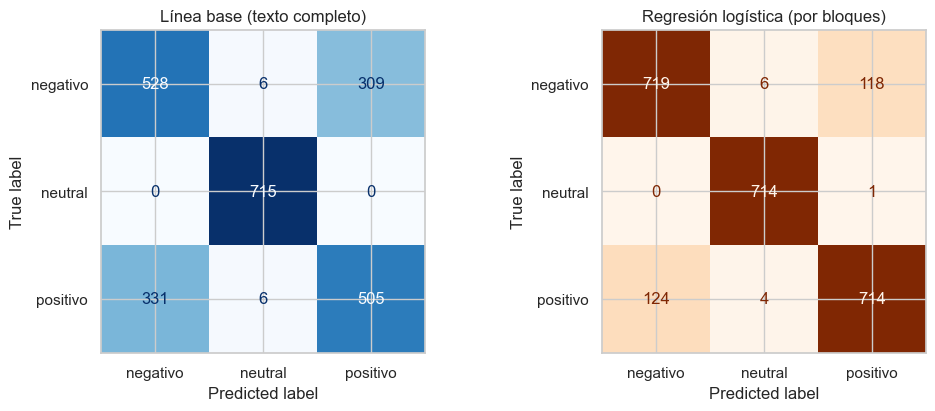

In [26]:
y_pred_mejor = pd.Series(resultados[mejor_nombre]['y_pred'], index=y_test.index)
print(classification_report(y_test, y_pred_mejor, digits=3))

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base, labels=ORDEN_CLASES, cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Línea base (texto completo)')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mejor, labels=ORDEN_CLASES, cmap='Oranges', ax=ax[1], colorbar=False)
ax[1].set_title(f'{mejor_nombre} (por bloques)')
plt.show()

En el conjunto de prueba la regresión logística por bloques alcanza una exactitud de 0,895 y un F1-macro de 0,899, frente a 0,728 y 0,741 de la línea base. La mejora viene de `positivo` y `negativo` (F1 de 0,853 en ambas, frente a 0,61 y 0,62), mientras que `neutral` se mantiene casi perfecta (F1 de 0,992).

Para entender los errores que quedan se mira un grupo particular: las reseñas que terminan en una frase de cierre repetida. Se consideran "cierre" las oraciones finales que aparecen textualmente 10 o más veces en train, como "cada quien que juzgue". Este análisis solo sirve para interpretar los resultados y no hace parte del modelo.

In [27]:
def clave_oracion(oracion):
    return re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).strip()


# Oraciones finales que se repiten textualmente 10 o más veces en train
finales = Counter(clave_oracion(separar_oraciones(t)[-1]) for t in X_train['text'])
cierres = {o for o, n in finales.items() if n >= 10}
print(f'{len(cierres)} oraciones de cierre repetidas. Las más comunes:')
for oracion, n in finales.most_common(8):
    print(f'  {n:4d}  {oracion}')

termina_en_cierre = X_test['text'].map(lambda t: clave_oracion(separar_oraciones(t)[-1]) in cierres)
es_polar = y_test != 'neutral'
acierto = (y_test == y_pred_mejor)

grupos = pd.DataFrame({
    'reseñas positivas/negativas': [(es_polar & termina_en_cierre).sum(), (es_polar & ~termina_en_cierre).sum()],
    'exactitud': [acierto[es_polar & termina_en_cierre].mean(), acierto[es_polar & ~termina_en_cierre].mean()],
}, index=['Terminan en un cierre repetido', 'Terminan en otra oración'])
grupos.round(3)

19 oraciones de cierre repetidas. Las más comunes:
    99  cada quien que juzgue
    74  para gustos colores
    57  en fin ni fu ni fa
    57  sigo con dudas la verdad
    54  hay de todo como se ve
    53  queda a criterio de cada uno
    47  lo dejo a tu criterio
    46  no sabria bien que recomendar


,reseñas positivas/negativas,exactitud
Terminan en un cierre repetido,198,0.460
Terminan en otra oración,1487,0.902


In [28]:
ejemplos = y_test[es_polar & termina_en_cierre & ~acierto].index[:3]
for i in ejemplos:
    print(f'[real: {y_test[i]} | predicho: {y_pred_mejor[i]}]')
    for oracion in separar_oraciones(X_test.loc[i, 'text']):
        print('   -', oracion)
    print()

[real: negativo | predicho: positivo]
   - La ergonomía vale totalmente la pena.
   - De paso, le pondría una estrella al botón de encendido.
   - Todavía no me decido.

[real: negativo | predicho: positivo]
   - Lo pedí a mediados de mes y me llegó en unos cinco días, en caja cerrada y todo bien embalado.
   - La conexión no es para nada lo que esperaba.
   - Lo estuve probando en la sala con mi laptop, que es donde más lo uso.
   - Quedé encantado con el cable.
   - Tengo sentimientos encontrados.

[real: positivo | predicho: negativo]
   - Lo compré a mediados de año porque lo necesitaba para el cuarto donde trabajo desde casa, y el sistema de sonido me dio más de un dolor de cabeza.
   - El envío tardó como cuatro días, nada fuera de lo normal.
   - Por cierto, cada peso que pagué por el ventilador valió la pena, lo tengo corriendo casi todas las tardes.
   - Cada quien que juzgue.



De las 1.685 reseñas positivas o negativas del conjunto de prueba, 198 (11,7%) terminan en una de esas 19 frases de cierre. En ese grupo la exactitud es de 0,46, equivalente a adivinar entre dos clases, mientras que en el resto es de 0,902. Con esas cifras, el grupo de cierres explica alrededor de 4 de cada 10 errores del modelo (cerca de 107 de unos 253), siendo solo el 8% de las reseñas.

Los ejemplos muestran por qué: son reseñas con una opinión positiva y otra negativa seguidas de una frase que no se inclina por ninguna. En el segundo ejemplo, "Quedé encantado con el cable. Tengo sentimientos encontrados" está etiquetada como `negativo`, aunque la opinión que aparece al final es positiva. Estas reseñas parecen ambiguas por naturaleza: ningún modelo que use solo el texto puede decidir de forma confiable entre las dos etiquetas. Es un límite de los datos y no tanto del modelo.

El resto de los errores (unos 146) está en reseñas que terminan en otra oración, y ahí la exactitud es de 0,90.

## 12. Interpretación del modelo

Como la regresión logística es un modelo lineal, sus coeficientes permiten ver qué atributos empujan hacia cada clase (con el solver `liblinear` se entrena un clasificador por clase, uno contra el resto). El nombre de cada atributo indica el bloque del que viene y la raíz de la palabra, por el stemming; por ejemplo, "ultima: chapucer" corresponde a "chapucera" o "chapucero" en la última oración. La regularización L1 deja en cero a la mayoría de los atributos.

In [29]:
rep_ajustada = mejor_modelo.named_steps['rep']
nombres = []
for bloque in ['completo', 'ultima', 'clausula']:
    vocabulario = rep_ajustada.named_transformers_[bloque].named_steps['tfidf'].get_feature_names_out()
    nombres.extend([f'{bloque}: {t}' for t in vocabulario])

coeficientes = pd.DataFrame(mejor_modelo.named_steps['modelo'].coef_.T,
                            index=np.array(nombres), columns=mejor_modelo.classes_)

print('Número total de atributos:', len(nombres))
print('Atributos con coeficiente distinto de cero:', (coeficientes != 0).any(axis=1).sum())

for clase in ['positivo', 'negativo']:
    print(f'\nAtributos que más empujan hacia "{clase}":')
    display(coeficientes[clase].sort_values(ascending=False).head(15).round(2).to_frame('coeficiente'))

Número total de atributos: 71049
Atributos con coeficiente distinto de cero: 3297

Atributos que más empujan hacia "positivo":


,coeficiente
completo: sin pens,32.93
completo: cinc estrell,30.83
clausula: potent,27.21
completo: super tod,27.16
completo: respondi tal,27.01
completo: cumpl de,26.79
clausula: excelent,26.61
clausula: superior,25.39
clausula: estupend,24.91
clausula: nit,23.67



Atributos que más empujan hacia "negativo":


,coeficiente
completo: ni regal,33.11
clausula: inest,29.87
ultima: chapucer,29.15
clausula: malisim,27.57
ultima: poc fiabl,27.54
clausula: desagrad,26.53
completo: termin hart,24.52
completo: de ten,24.16
clausula: pobr,22.95
ultima: floj,22.76


In [30]:
peso_por_bloque = (coeficientes.abs().groupby(lambda n: n.split(':')[0]).sum()
                   .loc[['completo', 'ultima', 'clausula']])
(peso_por_bloque / peso_por_bloque.sum()).round(3)

,negativo,neutral,positivo
completo,0.539,0.718,0.551
ultima,0.247,0.158,0.232
clausula,0.214,0.124,0.217


De los 71.049 atributos solo 3.297 (4,6%) tienen coeficiente distinto de cero en alguna clase. Los atributos con más peso son los esperables: palabras de valoración positiva ("excelente", "estupendo", "superior", "espectacular", "feliz", "cinco estrellas") empujan hacia `positivo`, y palabras de queja ("chapucera", "malísimo", "inestable", "poco fiable", "frágil", "ni regalado", "estoy arrepentido") hacia `negativo`. Varios de los atributos con más peso vienen de los bloques de última oración y cláusula final, lo que confirma que el modelo usa esa información.

La tabla de pesos por bloque muestra que para `neutral` el 72% del peso absoluto de los coeficientes está en el texto completo, es decir, el modelo reconoce las reseñas neutrales por su contenido general (descripciones de características). Para `positivo` y `negativo`, en cambio, entre el 45% y el 46% del peso está en los bloques de última oración y cláusula final, que cubren solo una pequeña parte del texto.

## 13. Modelo final y predicciones para la competencia

La configuración elegida en la sección 10 se vuelve a entrenar con las 12.000 reseñas etiquetadas (en lugar de solo el 80% usado para seleccionar), ya que más datos suelen dar un modelo ligeramente mejor, y con ese modelo se predicen las 3.000 reseñas de `eval.csv`. Los hiperparámetros no se vuelven a buscar: son los que seleccionó la validación cruzada.

Antes de entrenar, se estima el desempeño esperado de esta configuración con validación cruzada sobre todos los datos etiquetados.

In [31]:
# Estimación del desempeño de la configuración elegida usando todos los datos etiquetados
cv_acc = cross_val_score(clone(mejor_modelo), X, y, cv=kfold, scoring='accuracy', n_jobs=-1)
cv_f1 = cross_val_score(clone(mejor_modelo), X, y, cv=kfold, scoring='f1_macro', n_jobs=-1)
print(f'Exactitud en validación cruzada (12.000 reseñas): {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'F1-macro en validación cruzada (12.000 reseñas):  {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')

Exactitud en validación cruzada (12.000 reseñas): 0.8950 +/- 0.0030
F1-macro en validación cruzada (12.000 reseñas):  0.8994 +/- 0.0030


In [32]:
modelo_final = clone(mejor_modelo)
modelo_final.fit(X, y)

pred_eval = modelo_final.predict(evaluacion[['text']])
envio = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)

print('Parámetros del modelo final:')
print(modelo_final.named_steps['modelo'].get_params())
envio.head()

Parámetros del modelo final:
{'C': 10, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 3000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l1', 'random_state': 42, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


In [33]:
# Verificaciones del archivo de envío
print('Mismas columnas que sample_submission:', list(envio.columns) == list(muestra_envio.columns))
print('Mismo número de filas:', len(envio) == len(muestra_envio))
print('Mismos ids y en el mismo orden:', (envio['id'] == muestra_envio['id']).all())
print('Valores nulos:', envio['answer'].isna().sum())

comparacion = pd.DataFrame({'train (real)': train['label'].value_counts(normalize=True),
                            'eval (predicho)': envio['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES)
comparacion.round(3)

Mismas columnas que sample_submission: True
Mismo número de filas: True
Mismos ids y en el mismo orden: True
Valores nulos: 0


,train (real),eval (predicho)
negativo,0.351,0.355
neutral,0.298,0.281
positivo,0.351,0.364


In [34]:
ruta_modelo = os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib')
joblib.dump(modelo_final, ruta_modelo)

modelo_cargado = joblib.load(ruta_modelo)
pred_cargado = modelo_cargado.predict(evaluacion[['text']])
print('El modelo guardado reproduce exactamente las mismas predicciones:', (pred_cargado == pred_eval).all())

El modelo guardado reproduce exactamente las mismas predicciones: True


La validación cruzada sobre las 12.000 reseñas da una exactitud de 0,895 ± 0,003 y un F1-macro de 0,899 ± 0,003, consistente con lo observado en el conjunto de prueba. Este es el desempeño que se espera en la competencia, aunque el puntaje en Kaggle puede variar un poco por tratarse de otra muestra de 3.000 reseñas (diferencias de un punto o menos serían normales).

El archivo de envío (`submissions/submission_regresion_logistica_bloques.csv`) tiene el mismo formato que `sample_submission.csv` y las predicciones tienen una distribución de clases parecida a la de entrenamiento (35,5% `negativo`, 28,1% `neutral` y 36,4% `positivo`). El modelo guardado en `models/regresion_logistica_bloques.joblib` reproduce exactamente las mismas predicciones.

## 14. Conclusiones

- La tarea tiene dos partes de dificultad muy distinta. Separar `neutral` de las reseñas con opinión es sencillo (F1 de 0,99 incluso con la línea base). Separar `positivo` de `negativo` es lo difícil, porque muchas reseñas mezclan opiniones de signo contrario.
- Una bolsa de palabras sobre el texto completo, que es lo que se haría siguiendo literalmente la práctica de representación de texto, llega a un F1-macro de 0,74. Al revisar los errores se encontró que la etiqueta la define sobre todo la opinión del final de la reseña. Representar por separado el texto completo, la última oración y la cláusula posterior al último conector de contraste, todo con TF-IDF y n-gramas dentro de un `Pipeline`, sube el F1-macro a 0,90 sin salirse de las técnicas del curso.
- Entre los algoritmos, la regresión logística (L1, C = 10) es la mejor, seguida de Naive Bayes. Random Forest, KNN y el árbol de decisión rinden bastante peor sobre matrices dispersas de más de 70.000 columnas.
- Las stop words empeoraron el resultado, porque la lista de NLTK elimina palabras de negación y contraste ("no", "pero", "sin", "muy") que son importantes en opiniones. El stemming no cambió el resultado de la línea base y los n-gramas de caracteres tampoco ayudaron.
- Hay un límite de ruido. Alrededor del 12% de las reseñas positivas o negativas terminan en una frase de cierre ambigua y en ellas el modelo acierta cerca del azar (0,46). Esas reseñas explican alrededor de 4 de cada 10 errores, lo que sugiere que con solo el texto el desempeño máximo probablemente no esté muy por encima del actual.
- **Limitaciones:** la representación por bloques supone que la opinión importante está al final de la reseña y usa una lista de conectores definida a mano a partir del conjunto de entrenamiento; si las reseñas de otro dominio tuvieran otra estructura habría que revisarla. Además, una representación de bolsa de palabras no entiende el significado: "cumple de sobra" y "valió la pena" son atributos distintos aunque expresen lo mismo. Ese es el tipo de limitación que se aborda con las técnicas de la segunda parte del curso.

## 15. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (modelo Claude Sonnet 5.5, de Anthropic) como apoyo para: explorar los datos y el material de clase, generar un primer esqueleto del código del notebook, depurar un error de serialización al usar `n_jobs=-1` y redactar las explicaciones del notebook.

**Prompts utilizados.**

1. Se compartió el texto de la sección 4 de la guía del proyecto ("Parte 1: Machine Learning clásico", con sus requisitos técnicos) y se pidió: *"necesito que me ayudes a hacer la primera parte de este proyecto [...] recuerda seguir las indicaciones y restricciones indicadas en la guía [...] enfócate en el material de clase y en seguir las estrategias del material de clase; no te inventes cosas que nosotros no sabemos"*. Se dio acceso a las carpetas del material de clase y de los laboratorios anteriores del equipo.

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

**Aportes propios del equipo.**

[Completar por el equipo: qué se desarrolló, modificó o decidió, qué ajustes se hicieron al código y a las explicaciones, y qué se aprendió del proceso.]

## 16. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (las versiones exactas están en ese archivo).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/` y los datos (`train.csv`, `eval.csv`, `sample_submission.csv`) en `data/`. El notebook se ejecuta desde la carpeta `notebooks/`.
3. Ejecutar todas las celdas en orden (`Restart & Run All`). La primera celda descarga las stop words de NLTK, por lo que necesita conexión a internet esa vez. El notebook completo tarda alrededor de 15 minutos por las búsquedas de hiperparámetros.
4. Al terminar se regeneran `submissions/submission_regresion_logistica_bloques.csv` y `models/regresion_logistica_bloques.joblib`.

Todas las fuentes de aleatoriedad usan `RANDOM_STATE = 42`: la partición train/test, la validación cruzada y los modelos que usan azar (árbol, Random Forest y el solver `liblinear` de la regresión logística). Con las mismas versiones de las librerías, las cifras de este notebook se reproducen exactamente.

Para usar el modelo guardado fuera del notebook hay que ejecutar antes las celdas que definen las funciones de preprocesamiento (secciones 5, 7 y 8), porque el pipeline guardado hace referencia a ellas. Después basta con:

```python
modelo = joblib.load('../models/regresion_logistica_bloques.joblib')
predicciones = modelo.predict(evaluacion[['text']])
```